In [50]:
import json
from typing import Optional, Dict, Any

def load_from_json(filepath: str) -> Dict[str, Any]:
    """save_to_json으로 저장한 JSON 파일을 다시 dictionary로 불러옵니다."""
    with open(filepath, "r", encoding="utf-8") as f:
        return json.load(f)

In [51]:
k1 = load_from_json('./kanana1.json')
k2 = load_from_json('./kanana2.json')
k3 = load_from_json('./kanana3.json')

s1 = load_from_json('./skt1.json')
s2 = load_from_json('./skt2.json')
s3 = load_from_json('./skt3.json')

In [48]:
"""
카나나(Kanana) 그룹: k1, k2, k3 (동일 데이터 3회 반복 실행)
SKT 그룹: s1, s2, s3 (동일 데이터 3회 반복 실행)

각 dict는 이전 단계에서 만든 형식입니다.
{ run_id: { "input": {...},
            "node_ner": {"output":..., "latency":...},
            "node_preprocess": {...},
            "node_location_type_classify": {...},
            "node_address_parser": {...},
            "node_linear_parser": {...},
            "node_between_parser": {...},
            "node_busstop_parser": {...},
            "node_subway_parser": {...} } }

이 스크립트는:
1) node_ner / node_preprocess / node_location_type_classify 는 그대로 집계
2) node_*_parser 5개는 run마다 latency가 가장 큰 1개만 "parser" 노드로 집계
   (실제로 LLM이 생성을 수행한 노드만 의미있는 latency를 가지기 때문)
3) 그룹(kanana/skt) x 노드별로 평균 latency, 최대 latency, 평균 토큰 수를 계산
4) 노드별로 그래프를 그려서 kanana(파란색) vs skt(주황색) 비교
   - 막대 높이 = 평균 latency
   - 빨간 마커 + 점선 = 최대 latency
   - x축 라벨에 평균 토큰 길이 표시

사전 준비:
    pip install transformers matplotlib numpy
"""

import json
from typing import Any, Dict, List

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from transformers import AutoTokenizer

# ---------------------------------------------------------------------------
# 한글 폰트 설정 (시스템에 맞게 한 줄만 선택해서 사용하세요. 없으면 한글이 깨집니다)
# Mac:     plt.rcParams['font.family'] = 'AppleGothic'
# Windows: plt.rcParams['font.family'] = 'Malgun Gothic'
# Linux:   nanum 폰트 설치 후 plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'NanumGothic'

PARSER_NODES = [
    "node_address_parser",
    "node_linear_parser",
    "node_between_parser",
    "node_busstop_parser",
    "node_subway_parser",
]

COMMON_NODES = [
    "node_ner",
    "node_preprocess",
    "node_location_type_classify",
]

# 그래프에 표시할 노드 목록 (parser는 5개를 합쳐서 1개로 표시)
DISPLAY_NODES = COMMON_NODES + ["parser"]


def count_tokens(output_obj: Any, tokenizer) -> int:
    """output(dict 등)을 문자열로 변환한 뒤 BERT 토크나이저로 토큰 수를 계산합니다."""
    if output_obj is None:
        return 0
    text = json.dumps(output_obj, ensure_ascii=False)
    return len(tokenizer.encode(text, add_special_tokens=False))


def extract_node_metrics(trace_dict: Dict[str, Any], tokenizer) -> List[Dict[str, Any]]:
    """
    하나의 trace_dict(예: k1)에서 run_id별로 {node_name: (latency, tokens)}를 만듭니다.
    parser는 5개 중 latency가 가장 큰 1개만 "parser"라는 이름으로 기록합니다.
    """
    records: List[Dict[str, Any]] = []

    for run_id, run_data in trace_dict.items():
        rec: Dict[str, Any] = {}

        for node_name in COMMON_NODES:
            node_data = run_data.get(node_name)
            if node_data is None:
                continue
            latency = node_data.get("latency") or 0.0
            tokens = count_tokens(node_data.get("output"), tokenizer)
            rec[node_name] = (latency, tokens)

        # parser 5개 중 latency가 가장 큰 것 = 실제로 LLM이 생성을 수행한 노드
        best_latency = -1.0
        best_tokens = 0
        for p_name in PARSER_NODES:
            node_data = run_data.get(p_name)
            if node_data is None:
                continue
            latency = node_data.get("latency") or 0.0
            if latency > best_latency:
                best_latency = latency
                best_tokens = count_tokens(node_data.get("output"), tokenizer)

        if best_latency >= 0:
            rec["parser"] = (best_latency, best_tokens)

        records.append(rec)

    return records


def collect_group_metrics(trace_dicts: List[Dict[str, Any]], tokenizer) -> Dict[str, Dict[str, List[float]]]:
    """
    같은 그룹의 여러 trace_dict (예: [k1, k2, k3])를 받아
    노드별로 모든 latency/tokens 값을 모읍니다.

    반환: {"node_ner": {"latency": [...], "tokens": [...]}, ..., "parser": {...}}
    """
    group_metrics = {node: {"latency": [], "tokens": []} for node in DISPLAY_NODES}

    for trace_dict in trace_dicts:
        for rec in extract_node_metrics(trace_dict, tokenizer):
            for node_name, (latency, tokens) in rec.items():
                group_metrics[node_name]["latency"].append(latency)
                group_metrics[node_name]["tokens"].append(tokens)

    return group_metrics


def summarize_group_metrics(group_metrics: Dict[str, Dict[str, List[float]]]) -> Dict[str, Dict[str, float]]:
    """노드별 평균 latency, 최대 latency, 평균 토큰 수를 계산합니다."""
    summary = {}
    for node_name, values in group_metrics.items():
        if not values["latency"]:
            continue
        summary[node_name] = {
            "mean_latency": float(np.mean(values["latency"])),
            "max_latency": float(np.max(values["latency"])),
            "mean_tokens": float(np.mean(values["tokens"])),
        }
    return summary


def plot_node_comparison(node_name: str, kanana_summary: dict, skt_summary: dict):
    """하나의 노드에 대해 kanana vs skt 비교 그래프 1개를 그립니다."""
    if node_name not in kanana_summary or node_name not in skt_summary:
        print(f"[skip] '{node_name}' 데이터가 없습니다.")
        return

    k_mean = kanana_summary[node_name]["mean_latency"]
    s_mean = skt_summary[node_name]["mean_latency"]
    k_max = kanana_summary[node_name]["max_latency"]
    s_max = skt_summary[node_name]["max_latency"]
    k_tok = kanana_summary[node_name]["mean_tokens"]
    s_tok = skt_summary[node_name]["mean_tokens"]

    means = [k_mean, s_mean]
    maxes = [k_max, s_max]
    colors = ["#4C72B0", "#DD8452"]  # kanana=파란색, skt=주황색
    x = np.arange(2)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.bar(x, means, color=colors, width=0.5, zorder=2)

    for xi, mean_v, max_v in zip(x, means, maxes):
        # 최대 latency: 점선 + 빨간 마커
        ax.plot([xi - 0.22, xi + 0.22], [max_v, max_v], color="red", linestyle="--", linewidth=1, zorder=3)
        ax.scatter([xi], [max_v], color="red", marker="D", s=40, zorder=4)
        ax.text(xi, max_v, f" max {max_v:.2f}s", color="red", fontsize=15, va="bottom", ha="center")
        # 막대 안에 평균 latency 값 표시
        ax.text(xi, mean_v / 2, f"{mean_v:.2f}s", color="white", fontsize=15,
                 ha="center", va="center", fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels([
        f"Kanana\n(avg tokens: {k_tok:.0f})",
        f"SKT\n(avg tokens: {s_tok:.0f})",
    ], fontsize=14)
    ax.set_ylabel("Latency (sec)", fontsize=14, labelpad=10)
    ax.set_ylim(0, max(maxes) * 1.25 if max(maxes) > 0 else 1)
    ax.set_title(node_name)

    legend_elements = [
        Patch(facecolor=colors[0], label="Kanana 평균 latency"),
        Patch(facecolor=colors[1], label="SKT 평균 latency"),
        Line2D([0], [0], marker='D', color='red', label='최대 latency', linestyle='None'),
    ]
    ax.legend(handles=legend_elements, fontsize=13, loc="upper right")

    plt.tight_layout()
    plt.show()


def plot_all_nodes(kanana_summary: dict, skt_summary: dict):
    """DISPLAY_NODES 순서대로 모든 노드 그래프를 그립니다."""
    for node_name in DISPLAY_NODES:
        plot_node_comparison(node_name, kanana_summary, skt_summary)


# ---------------------------------------------------------------------------
# 사용 예시 (Jupyter Notebook 셀에서 아래처럼 호출하시면 됩니다)
# ---------------------------------------------------------------------------
#
# tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
#
# kanana_group_metrics = collect_group_metrics([k1, k2, k3], tokenizer)
# skt_group_metrics    = collect_group_metrics([s1, s2, s3], tokenizer)
#
# kanana_summary = summarize_group_metrics(kanana_group_metrics)
# skt_summary    = summarize_group_metrics(skt_group_metrics)
#
# plot_all_nodes(kanana_summary, skt_summary)

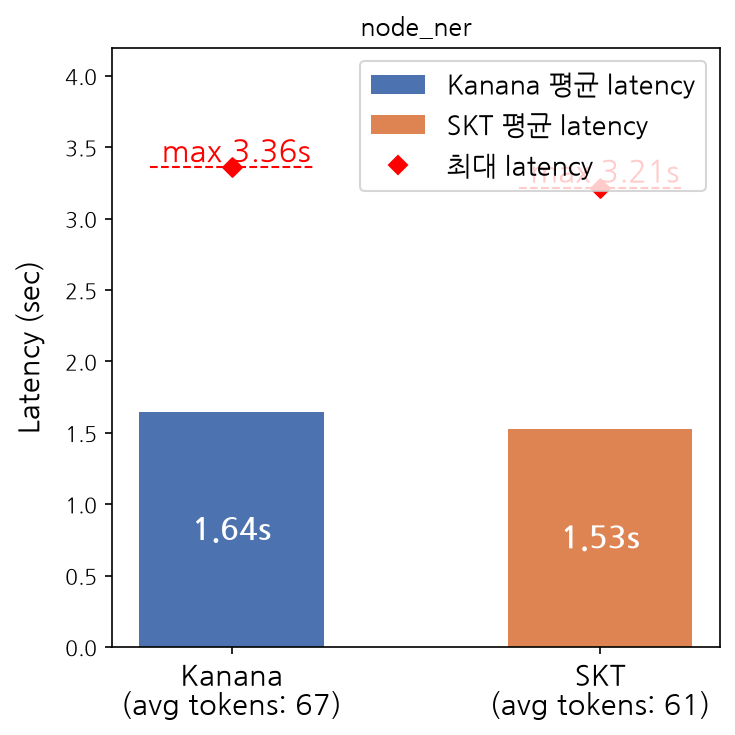

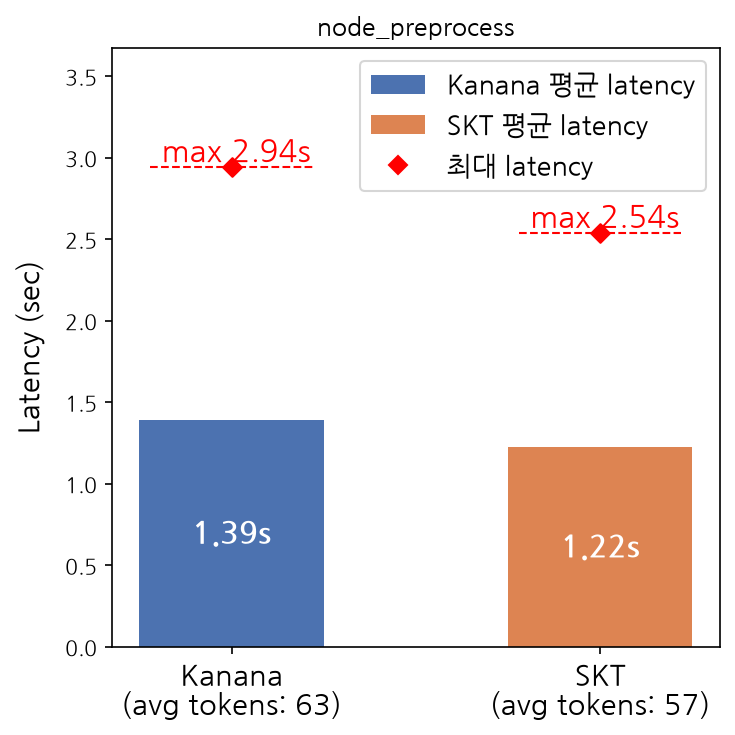

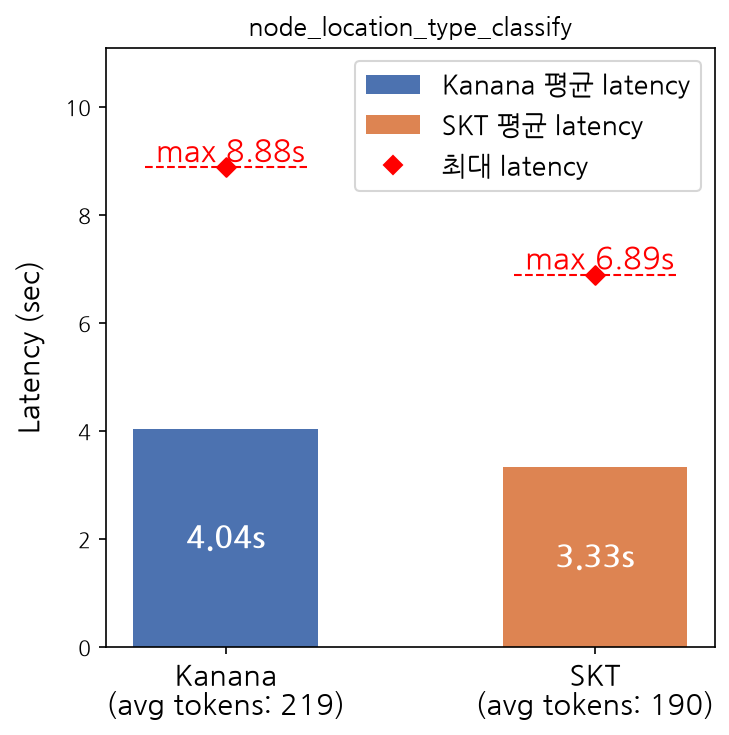

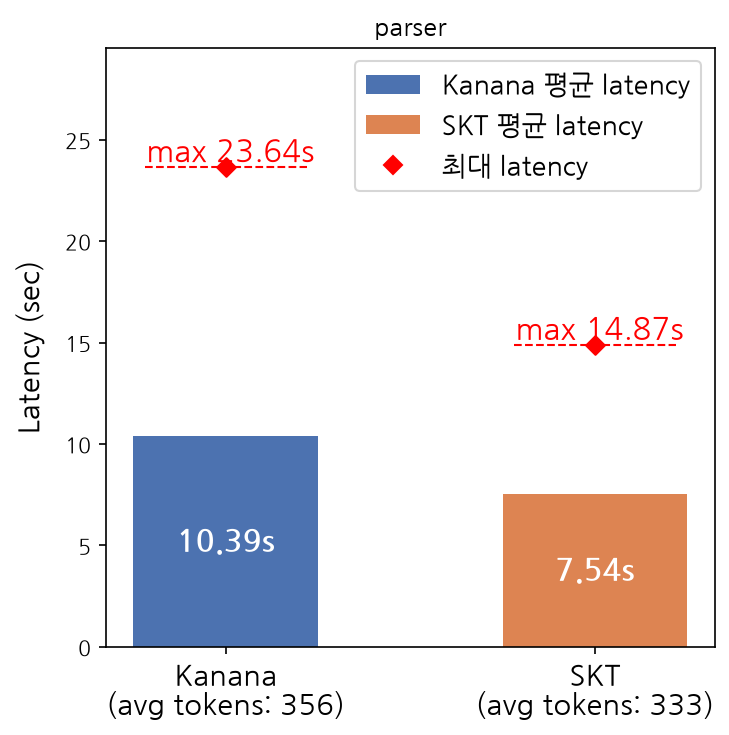

In [49]:
tokenizer = AutoTokenizer.from_pretrained("skt/kobert-base-v1")

kanana_group_metrics = collect_group_metrics([k1, k2, k3], tokenizer)
skt_group_metrics    = collect_group_metrics([s1, s2, s3], tokenizer)

kanana_summary = summarize_group_metrics(kanana_group_metrics)
skt_summary    = summarize_group_metrics(skt_group_metrics)

plot_all_nodes(kanana_summary, skt_summary)

In [54]:
import json
from typing import Any, Dict, List

import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

plt.rcParams['axes.unicode_minus'] = False


PARSER_NODES = [
    "node_address_parser",
    "node_linear_parser",
    "node_between_parser",
    "node_busstop_parser",
    "node_subway_parser",
]

COMMON_NODES = [
    "node_ner",
    "node_preprocess",
    "node_location_type_classify",
]

# 1920x1080 해상도를 인치 단위로 정밀 변환 (DPI 100 기준)
TARGET_FIGSIZE = (19.2, 10.8)

# 요구사항에 맞춰 시각화 대상 노드를 2개로 압축 조정
DISPLAY_NODES = ["node_location_type_classify", "parser"]


def count_tokens(output_obj: Any, tokenizer) -> int:
    if output_obj is None:
        return 0
    text = json.dumps(output_obj, ensure_ascii=False)
    return len(tokenizer.encode(text, add_special_tokens=False))


def extract_node_metrics(trace_dict: Dict[str, Any], tokenizer) -> List[Dict[str, Any]]:
    records: List[Dict[str, Any]] = []

    for run_id, run_data in trace_dict.items():
        rec: Dict[str, Any] = {}

        for node_name in COMMON_NODES:
            node_data = run_data.get(node_name)
            if node_data is None:
                continue
            latency = node_data.get("latency") or 0.0
            tokens = count_tokens(node_data.get("output"), tokenizer)
            rec[node_name] = (latency, tokens)

        best_latency = -1.0
        best_tokens = 0
        for p_name in PARSER_NODES:
            node_data = run_data.get(p_name)
            if node_data is None:
                continue
            latency = node_data.get("latency") or 0.0
            if latency > best_latency:
                best_latency = latency
                best_tokens = count_tokens(node_data.get("output"), tokenizer)

        if best_latency >= 0:
            rec["parser"] = (best_latency, best_tokens)

        records.append(rec)

    return records


def collect_group_metrics(trace_dicts: List[Dict[str, Any]], tokenizer) -> Dict[str, Dict[str, List[float]]]:
    group_metrics = {node: {"latency": [], "tokens": []} for node in DISPLAY_NODES}

    for trace_dict in trace_dicts:
        for rec in extract_node_metrics(trace_dict, tokenizer):
            for node_name, (latency, tokens) in rec.items():
                if node_name in DISPLAY_NODES:
                    group_metrics[node_name]["latency"].append(latency)
                    group_metrics[node_name]["tokens"].append(tokens)

    return group_metrics


def summarize_group_metrics(group_metrics: Dict[str, Dict[str, List[float]]]) -> Dict[str, Dict[str, float]]:
    summary = {}
    for node_name, values in group_metrics.items():
        if not values["latency"]:
            continue
        summary[node_name] = {
            "mean_latency": float(np.mean(values["latency"])),
            "max_latency": float(np.max(values["latency"])),
            "mean_tokens": float(np.mean(values["tokens"])),
        }
    return summary


def get_node_value(run_data: Dict[str, Any], node_name: str, tokenizer):
    if node_name == "parser":
        best_latency = -1.0
        best_tokens = 0
        found = False
        for p_name in PARSER_NODES:
            node_data = run_data.get(p_name)
            if node_data is None:
                continue
            latency = node_data.get("latency") or 0.0
            if latency > best_latency:
                best_latency = latency
                best_tokens = count_tokens(node_data.get("output"), tokenizer)
                found = True
        return (best_latency, best_tokens) if found else None

    node_data = run_data.get(node_name)
    if node_data is None:
        return None
    latency = node_data.get("latency") or 0.0
    tokens = count_tokens(node_data.get("output"), tokenizer)
    return latency, tokens


def collect_input_level_points(trace_dicts: List[Dict[str, Any]], node_name: str, tokenizer):
    runs_lists = [list(d.values()) for d in trace_dicts]
    n_inputs = min(len(r) for r in runs_lists)

    points = []
    for i in range(n_inputs):
        latencies, tokens_list = [], []
        for runs in runs_lists:
            result = get_node_value(runs[i], node_name, tokenizer)
            if result is None:
                continue
            latency, tokens = result
            latencies.append(latency)
            tokens_list.append(tokens)
        if latencies:
            points.append((float(np.mean(tokens_list)), float(np.mean(latencies))))

    return points


def plot_node_on_ax(
    ax,
    node_name: str,
    kanana_dicts: List[Dict[str, Any]],
    skt_dicts: List[Dict[str, Any]],
    tokenizer,
):
    kanana_points = collect_input_level_points(kanana_dicts, node_name, tokenizer)
    skt_points = collect_input_level_points(skt_dicts, node_name, tokenizer)

    if not kanana_points and not skt_points:
        ax.set_title(f"{node_name} (No Data)", fontsize=18, fontweight='bold', pad=15)
        return []

    lines_for_legend = []

    for label, points, color in [
        ("Kanana", kanana_points, "#4C72B0"),
        ("SKT", skt_points, "#DD8452"),
    ]:
        if not points:
            continue

        pts_sorted = sorted(points, key=lambda p: p[0])
        xs = [p[0] for p in pts_sorted]
        ys = [p[1] for p in pts_sorted]

        scatter_line, = ax.plot(xs, ys, marker="o", linestyle="None", color=color, alpha=0.8,
                                markersize=7)
        
        if len(xs) >= 2:
            coeffs = np.polyfit(xs, ys, deg=1)
            trend_x = np.linspace(min(xs), max(xs), 100)
            trend_y = np.polyval(coeffs, trend_x)
            trend_line, = ax.plot(trend_x, trend_y, linestyle="--", color=color, alpha=0.6,
                                  linewidth=2.5)
            
            if len(lines_for_legend) < 4:
                lines_for_legend.append((scatter_line, label))
                lines_for_legend.append((trend_line, f"{label} 경향선"))

    ax.set_xlabel("평균 토큰 길이", fontsize=30, labelpad=10)
    ax.set_ylabel("평균 Latency (sec)", fontsize=30, labelpad=10)
    ax.set_title(node_name, fontsize=30, fontweight='bold', pad=15)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.grid(True, linestyle=":", alpha=0.6)
    
    return lines_for_legend


def plot_all_nodes_subplots(
    kanana_dicts: List[Dict[str, Any]],
    skt_dicts: List[Dict[str, Any]],
    tokenizer,
):
    fig, axes = plt.subplots(1, 2, figsize=TARGET_FIGSIZE)
    
    global_legend_items = {}

    for idx, node_name in enumerate(DISPLAY_NODES):
        extracted_lines = plot_node_on_ax(axes[idx], node_name, kanana_dicts, skt_dicts, tokenizer)
        for line, label in extracted_lines:
            if label not in global_legend_items:
                global_legend_items[label] = line

    # if global_legend_items:
    #     labels = list(global_legend_items.keys())
    #     handles = list(global_legend_items.values())
    #     fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.05, 0.90), 
    #                fontsize=30, frameon=True, facecolor='white', edgecolor='#e0e0e0')

    plt.tight_layout()
    
    plt.savefig('my_graph.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_all_nodes(
    kanana_dicts: List[Dict[str, Any]],
    skt_dicts: List[Dict[str, Any]],
    tokenizer,
):
    plot_all_nodes_subplots(kanana_dicts, skt_dicts, tokenizer)

findfont: Failed to find font weight bold, now using 600.


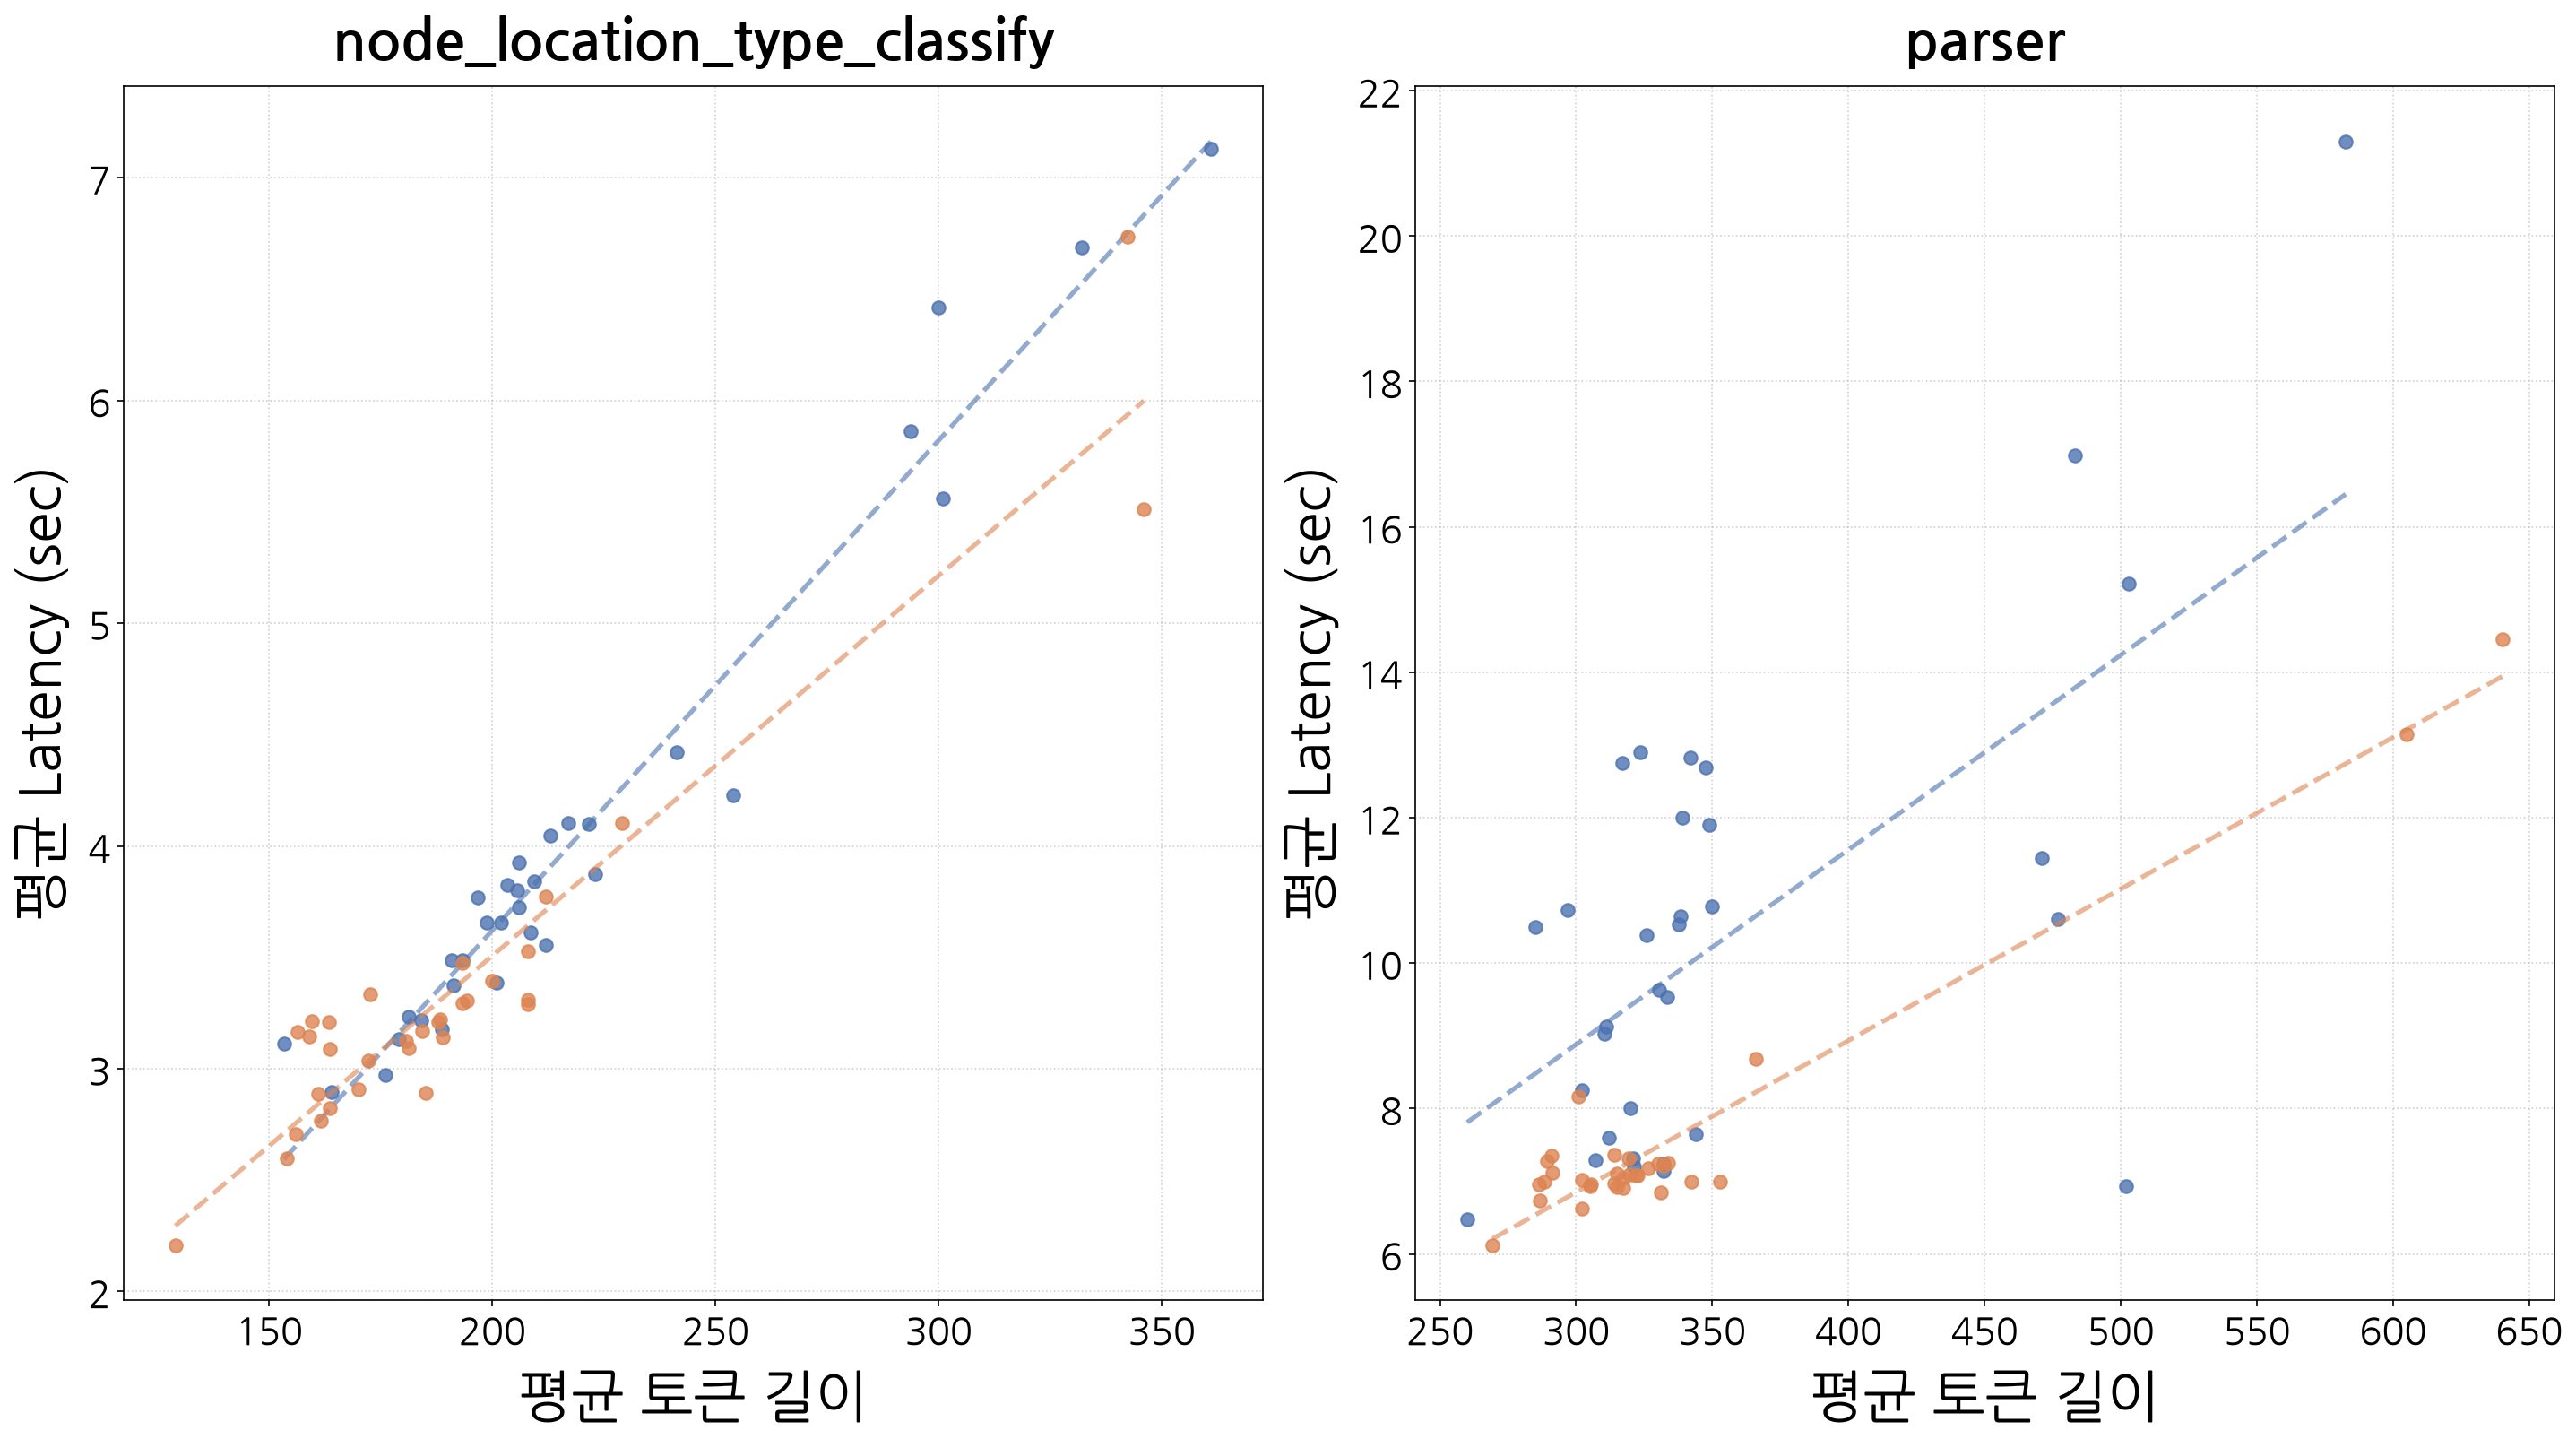

In [55]:
tokenizer = AutoTokenizer.from_pretrained("skt/kobert-base-v1")

kanana_dicts = [k1, k2, k3]   # kakaocorp/kanana-1.5-8b-instruct-2505
skt_dicts    = [s1, s2, s3]   # skt/A.X-3.1-Light

plot_all_nodes(kanana_dicts, skt_dicts, tokenizer)

In [3]:
"""
Run-level Average 평가를 위한 사람 평가용 CSV 생성 스크립트.

- Kanana 그룹: k1, k2, k3 (동일 입력 데이터 3회 반복 실행)
- SKT 그룹:    s1, s2, s3 (동일 입력 데이터 3회 반복 실행)

CSV는 input 1개당 1행으로 구성되며,
- "input" 컬럼에는 실제 입력 데이터를 채워 넣습니다.
- 나머지 평가 항목 컬럼은 전부 빈 값(None)으로 두어, 사람이 직접 점수를 입력하도록 합니다.
  (3회 반복 실행을 각각 채점하지 않고, input 1개에 대해 1번만 채점합니다.)

input은 k1, k2, k3 (또는 s1, s2, s3)가 동일한 순서로 동일한 데이터를 처리했다는
가정 하에 첫 번째 dict(예: k1)를 기준으로 추출합니다.
"""

import csv
import json
from typing import Any, Dict, List

# ---------------------------------------------------------------------------
# 평가 항목 정의 (노드별 평가 기준을 컬럼 헤더로 사용)
# ---------------------------------------------------------------------------
EVALUATION_COLUMNS: List[str] = [
    "node_ner: entity가 모두 잘 뽑혔는가? / entity 별로 통제, 우회인지 잘 분류되어 있는가?",
    "node_preprocess: entity가 원하는 형태로 변경되었는가?",
    "node_location_type_classify: entity가 올바른 형태인가? / location_type이 잘 분류되었는가?",
    "node_*_parser: road_name, start_node, end_node 등이 잘 매칭되었는가? / location_type이 잘 유지되었는가? / startDateTime과 endDateTime이 잘 적혔는가?",
]


def build_evaluation_csv(trace_dicts: List[Dict[str, Any]], output_csv_path: str) -> None:
    """
    동일 입력 데이터를 반복 실행한 trace_dict 리스트(예: [k1, k2, k3])를 받아
    input별 1행 + 평가 항목 빈 컬럼을 가진 csv를 생성합니다.

    Args:
        trace_dicts: 같은 그룹의 반복 실행 dict 리스트 (예: [k1, k2, k3] 또는 [s1, s2, s3])
        output_csv_path: 저장할 csv 파일 경로
    """
    lengths = [len(d) for d in trace_dicts]
    if len(set(lengths)) > 1:
        print(f"[경고] 반복 실행 dict들의 input 개수가 다릅니다: {lengths}. "
              f"가장 적은 개수({min(lengths)})만큼만 사용합니다.")

    n_inputs = min(lengths)
    base_runs = list(trace_dicts[0].values())  # input은 첫 번째 반복(예: k1) 기준으로 추출

    rows = []
    for i in range(n_inputs):
        run_data = base_runs[i]
        row: Dict[str, Any] = {
            "input": json.dumps(run_data.get("input"), ensure_ascii=False)
        }
        for col_name in EVALUATION_COLUMNS:
            row[col_name] = None  # 사람이 직접 채울 빈 칸 (csv에는 빈 셀로 저장됨)
        rows.append(row)

    fieldnames = ["input"] + EVALUATION_COLUMNS

    with open(output_csv_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"{len(rows)}개 input에 대한 평가용 csv가 생성되었습니다 -> {output_csv_path}")


# ---------------------------------------------------------------------------
# 사용 예시 (Jupyter Notebook 셀에서 아래처럼 호출하시면 됩니다)
# ---------------------------------------------------------------------------
#
build_evaluation_csv([k1, k2, k3], "kanana_evaluation.csv")
build_evaluation_csv([s1, s2, s3], "skt_evaluation.csv")

32개 input에 대한 평가용 csv가 생성되었습니다 -> kanana_evaluation.csv
32개 input에 대한 평가용 csv가 생성되었습니다 -> skt_evaluation.csv


In [3]:
import pandas as pd

In [17]:
kanana = pd.read_csv('./kanana_evaluation2.csv')
skt = pd.read_csv('./skt_evaluation2.csv')

In [12]:
def dedup(dataframe):
    """
    'input' 열에서 '\r' 문자를 제거한 뒤, 'input' 기준으로 중복된 행을 제거합니다.
    """
    df = dataframe.copy()
    df['input'] = df['input'].astype(str).str.replace('\r', ' ', regex=False)
    df = df.drop_duplicates(subset=['input']).reset_index(drop=True)
    return df

In [13]:
dropped_k = dedup(kanana)
dropped_s = dedup(skt)

In [19]:
def average_score_per_column(dataframe: pd.DataFrame, exclude_cols=None) -> pd.Series:
    """
    DataFrame에서 'input'처럼 점수가 아닌 컬럼을 제외하고,
    나머지 컬럼별 평균 점수를 계산합니다.
    """
    exclude_cols = exclude_cols or ['input']
    score_cols = [c for c in dataframe.columns if c not in exclude_cols]

    # 혹시 점수가 문자열로 들어있을 경우를 대비해 숫자로 변환 (변환 안 되면 NaN 처리)
    scores = dataframe[score_cols].apply(pd.to_numeric, errors='coerce')

    return scores.mean()

In [20]:
average_score_per_column(kanana)

node_ner                       0.953125
node_preprocess                0.921875
node_location_type_classify    0.890625
node_*_parser                  0.781250
dtype: float64

In [22]:
average_score_per_column(skt)

node_ner                       0.625000
node_preprocess                0.651000
node_location_type_classify    0.723938
node_*_parser                  0.791656
dtype: float64

In [56]:
import json
from typing import Any, Dict, List

import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

plt.rcParams['axes.unicode_minus'] = False


PARSER_NODES = [
    "node_address_parser",
    "node_linear_parser",
    "node_between_parser",
    "node_busstop_parser",
    "node_subway_parser",
]

COMMON_NODES = [
    "node_ner",
    "node_preprocess",
    "node_location_type_classify",
]

# 1920x1080 해상도를 인치 단위로 정밀 변환 (DPI 100 기준)
TARGET_FIGSIZE = (19.2, 10.8)

# 요구사항에 맞춰 시각화 대상 노드를 2개로 압축 조정
DISPLAY_NODES = ["node_location_type_classify", "parser"]


def count_tokens(output_obj: Any, tokenizer) -> int:
    if output_obj is None:
        return 0
    text = json.dumps(output_obj, ensure_ascii=False)
    return len(tokenizer.encode(text, add_special_tokens=False))


def extract_node_metrics(trace_dict: Dict[str, Any], tokenizer) -> List[Dict[str, Any]]:
    records: List[Dict[str, Any]] = []

    for run_id, run_data in trace_dict.items():
        rec: Dict[str, Any] = {}

        for node_name in COMMON_NODES:
            node_data = run_data.get(node_name)
            if node_data is None:
                continue
            latency = node_data.get("latency") or 0.0
            tokens = count_tokens(node_data.get("output"), tokenizer)
            rec[node_name] = (latency, tokens)

        best_latency = -1.0
        best_tokens = 0
        for p_name in PARSER_NODES:
            node_data = run_data.get(p_name)
            if node_data is None:
                continue
            latency = node_data.get("latency") or 0.0
            if latency > best_latency:
                best_latency = latency
                best_tokens = count_tokens(node_data.get("output"), tokenizer)

        if best_latency >= 0:
            rec["parser"] = (best_latency, best_tokens)

        records.append(rec)

    return records


def collect_group_metrics(trace_dicts: List[Dict[str, Any]], tokenizer) -> Dict[str, Dict[str, List[float]]]:
    group_metrics = {node: {"latency": [], "tokens": []} for node in DISPLAY_NODES}

    for trace_dict in trace_dicts:
        for rec in extract_node_metrics(trace_dict, tokenizer):
            for node_name, (latency, tokens) in rec.items():
                if node_name in DISPLAY_NODES:
                    group_metrics[node_name]["latency"].append(latency)
                    group_metrics[node_name]["tokens"].append(tokens)

    return group_metrics


def summarize_group_metrics(group_metrics: Dict[str, Dict[str, List[float]]]) -> Dict[str, Dict[str, float]]:
    summary = {}
    for node_name, values in group_metrics.items():
        if not values["latency"]:
            continue
        summary[node_name] = {
            "mean_latency": float(np.mean(values["latency"])),
            "max_latency": float(np.max(values["latency"])),
            "mean_tokens": float(np.mean(values["tokens"])),
        }
    return summary


def get_node_value(run_data: Dict[str, Any], node_name: str, tokenizer):
    if node_name == "parser":
        best_latency = -1.0
        best_tokens = 0
        found = False
        for p_name in PARSER_NODES:
            node_data = run_data.get(p_name)
            if node_data is None:
                continue
            latency = node_data.get("latency") or 0.0
            if latency > best_latency:
                best_latency = latency
                best_tokens = count_tokens(node_data.get("output"), tokenizer)
                found = True
        return (best_latency, best_tokens) if found else None

    node_data = run_data.get(node_name)
    if node_data is None:
        return None
    latency = node_data.get("latency") or 0.0
    tokens = count_tokens(node_data.get("output"), tokenizer)
    return latency, tokens


def collect_input_level_points(trace_dicts: List[Dict[str, Any]], node_name: str, tokenizer):
    runs_lists = [list(d.values()) for d in trace_dicts]
    n_inputs = min(len(r) for r in runs_lists)

    points = []
    for i in range(n_inputs):
        latencies, tokens_list = [], []
        for runs in runs_lists:
            result = get_node_value(runs[i], node_name, tokenizer)
            if result is None:
                continue
            latency, tokens = result
            latencies.append(latency)
            tokens_list.append(tokens)
        if latencies:
            points.append((float(np.mean(tokens_list)), float(np.mean(latencies))))

    return points


def plot_node_on_ax(
    ax,
    node_name: str,
    kanana_dicts: List[Dict[str, Any]],
    skt_dicts: List[Dict[str, Any]],
    tokenizer,
):
    kanana_points = collect_input_level_points(kanana_dicts, node_name, tokenizer)
    skt_points = collect_input_level_points(skt_dicts, node_name, tokenizer)

    if not kanana_points and not skt_points:
        ax.set_title(f"{node_name} (No Data)", fontsize=18, fontweight='bold', pad=15)
        return []

    lines_for_legend = []

    for label, points, color in [
        ("Kanana", kanana_points, "#4C72B0"),
        ("SKT", skt_points, "#DD8452"),
    ]:
        if not points:
            continue

        pts_sorted = sorted(points, key=lambda p: p[0])
        xs = [p[0] for p in pts_sorted]
        ys = [p[1] for p in pts_sorted]

        # 점 크기 확대(markersize=11) 및 투명도 상향(alpha=0.95) 반영
        scatter_line, = ax.plot(xs, ys, marker="o", linestyle="None", color=color, alpha=0.95,
                                markersize=11)
        
        if len(xs) >= 2:
            coeffs = np.polyfit(xs, ys, deg=1)
            trend_x = np.linspace(min(xs), max(xs), 100)
            trend_y = np.polyval(coeffs, trend_x)
            # 경향선 선 두께 상향(linewidth=4.5) 반영
            trend_line, = ax.plot(trend_x, trend_y, linestyle="--", color=color, alpha=0.6,
                                  linewidth=4.5)
            
            if len(lines_for_legend) < 4:
                lines_for_legend.append((scatter_line, label))
                lines_for_legend.append((trend_line, f"{label} 경향선"))

    ax.set_xlabel("평균 토큰 길이", fontsize=30, labelpad=10)
    ax.set_ylabel("평균 Latency (sec)", fontsize=30, labelpad=10)
    ax.set_title(node_name, fontsize=30, fontweight='bold', pad=15)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.grid(True, linestyle=":", alpha=0.6)
    
    return lines_for_legend


def plot_all_nodes_subplots(
    kanana_dicts: List[Dict[str, Any]],
    skt_dicts: List[Dict[str, Any]],
    tokenizer,
):
    fig, axes = plt.subplots(1, 2, figsize=TARGET_FIGSIZE)
    
    global_legend_items = {}

    for idx, node_name in enumerate(DISPLAY_NODES):
        extracted_lines = plot_node_on_ax(axes[idx], node_name, kanana_dicts, skt_dicts, tokenizer)
        for line, label in extracted_lines:
            if label not in global_legend_items:
                global_legend_items[label] = line

    # if global_legend_items:
    #      labels = list(global_legend_items.keys())
    #      handles = list(global_legend_items.values())
    #      fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.05, 0.90), 
    #                 fontsize=30, frameon=True, facecolor='white', edgecolor='#e0e0e0')

    plt.tight_layout()
    
    plt.savefig('my_graph.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_all_nodes(
    kanana_dicts: List[Dict[str, Any]],
    skt_dicts: List[Dict[str, Any]],
    tokenizer,
):
    plot_all_nodes_subplots(kanana_dicts, skt_dicts, tokenizer)

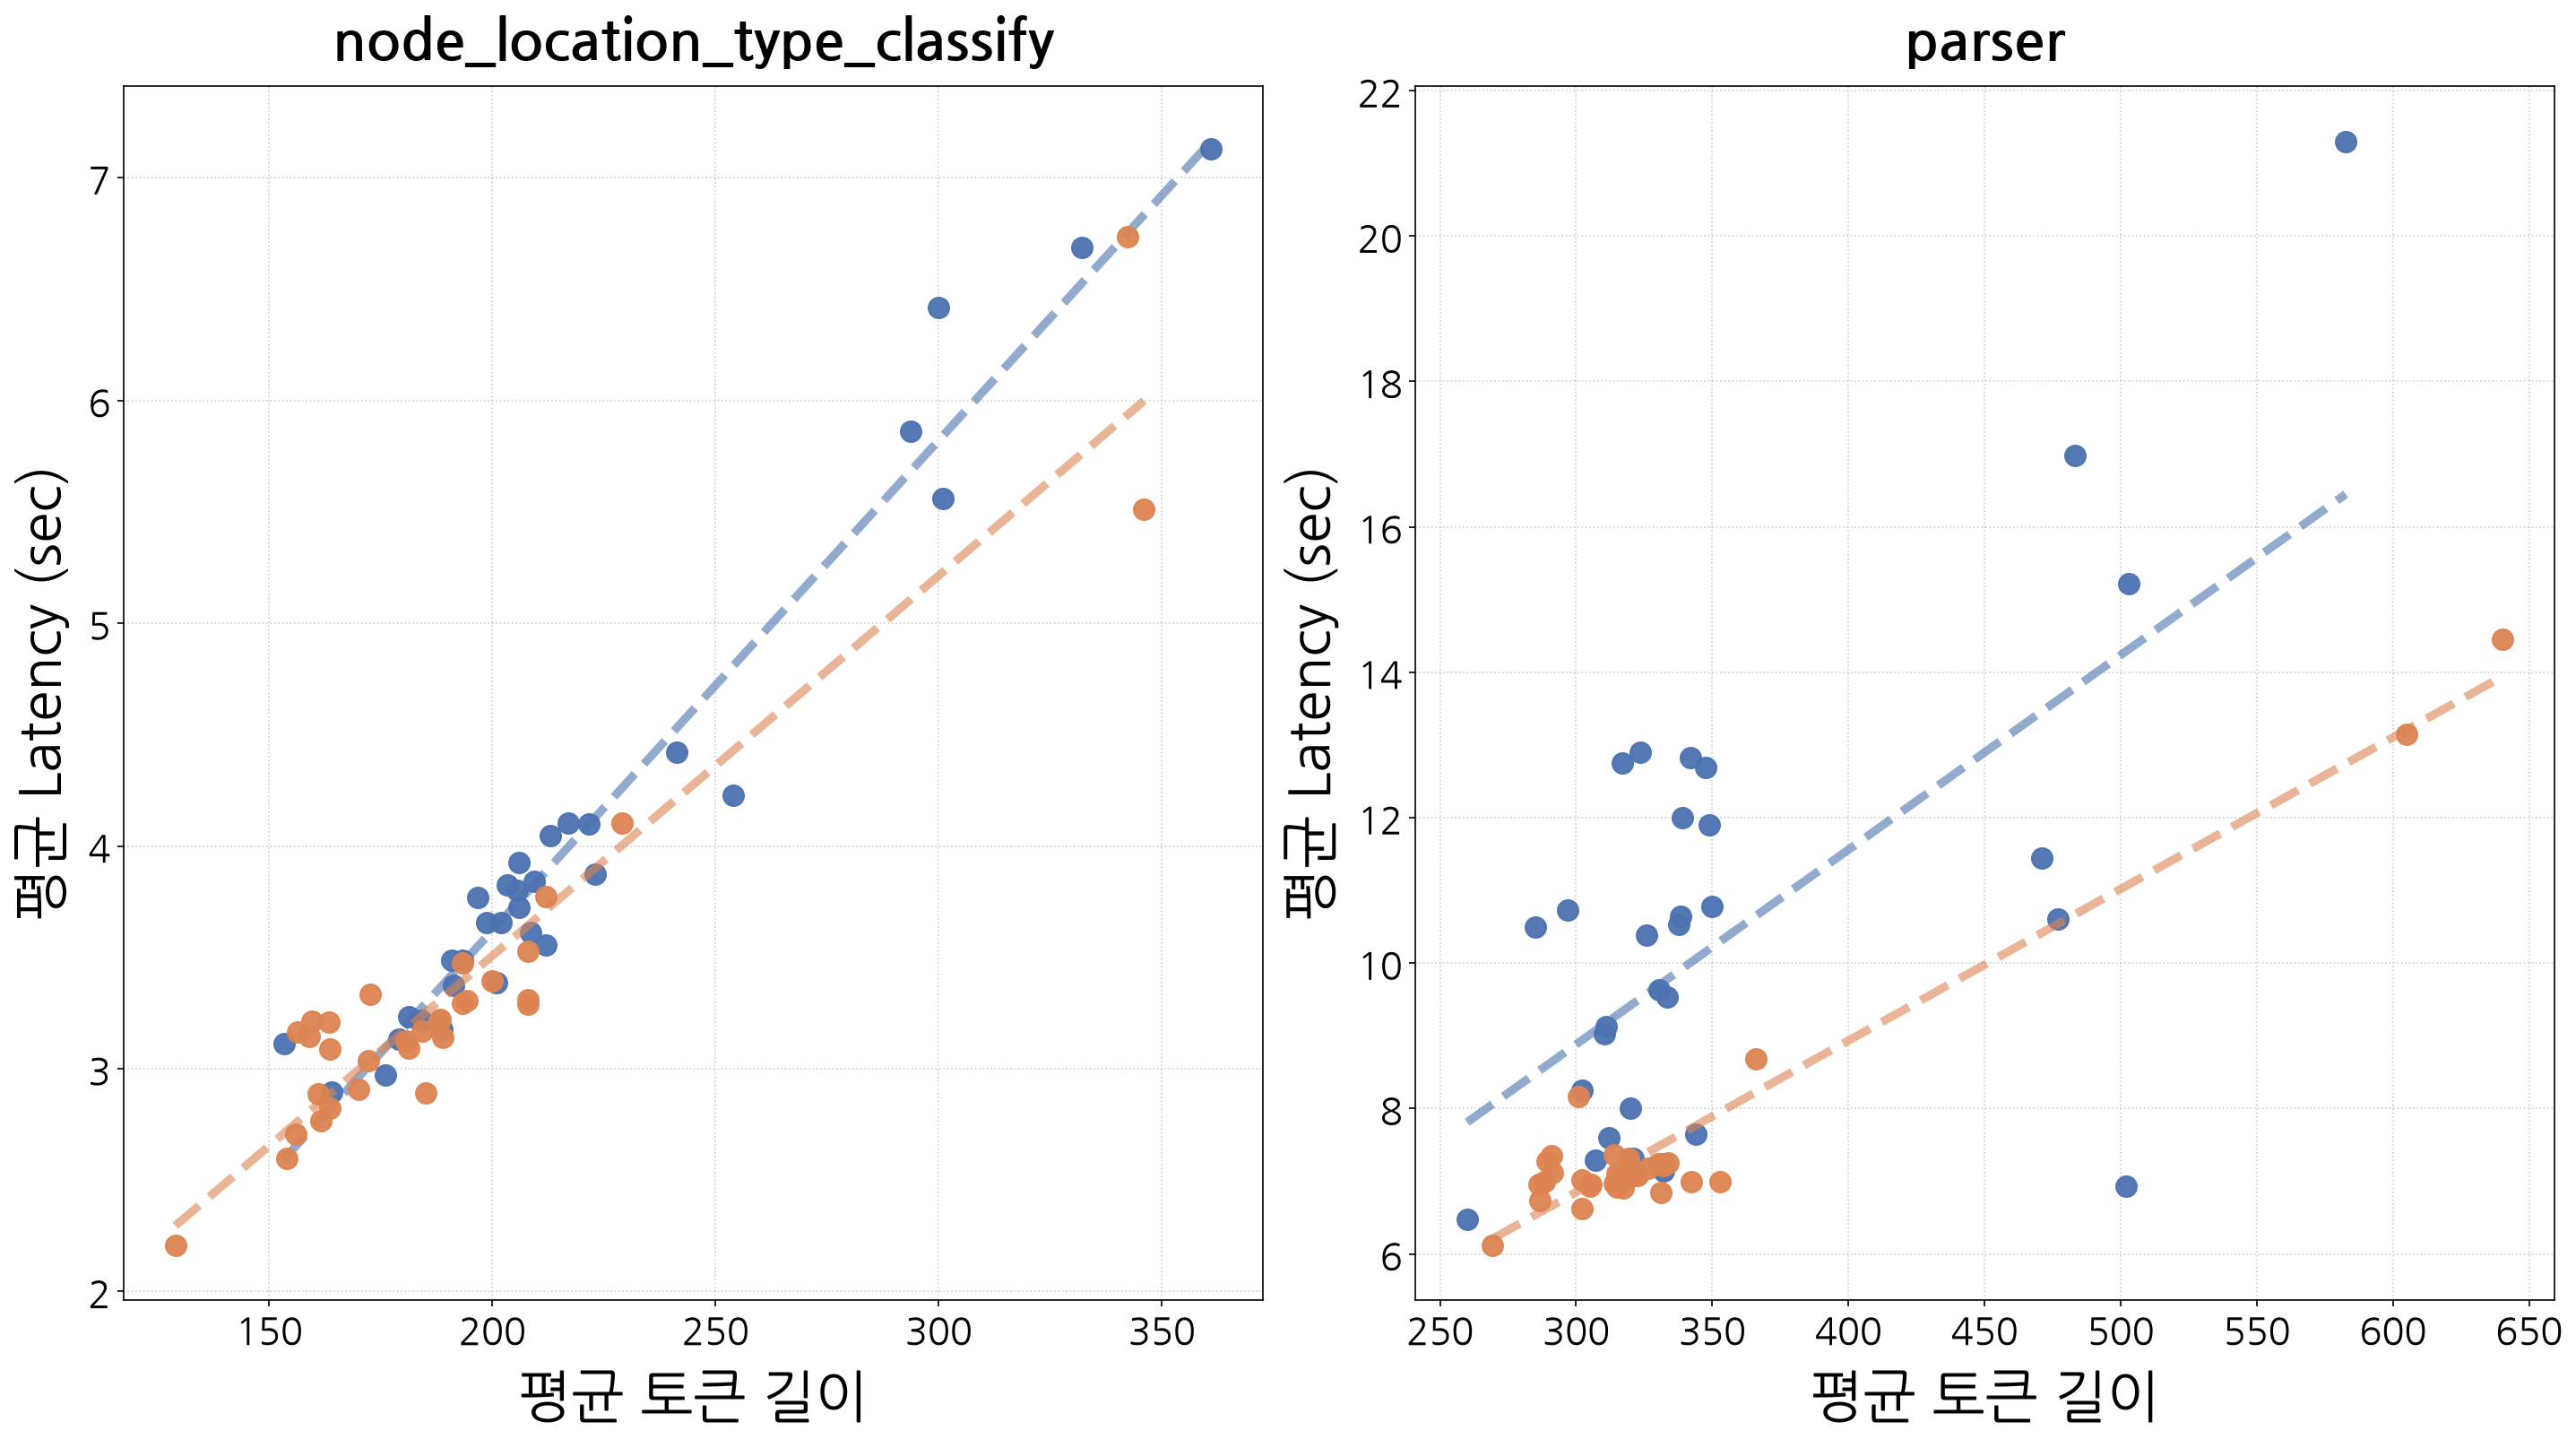

In [57]:
tokenizer = AutoTokenizer.from_pretrained("skt/kobert-base-v1")

kanana_dicts = [k1, k2, k3]   # kakaocorp/kanana-1.5-8b-instruct-2505
skt_dicts    = [s1, s2, s3]   # skt/A.X-3.1-Light

plot_all_nodes(kanana_dicts, skt_dicts, tokenizer)